In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,12))
sns.set_style("whitegrid")

<Figure size 1000x1200 with 0 Axes>

In [5]:
df = pd.read_excel("cleaned_data.xlsx")
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2022-01-01,Mouse,Accessories,East,3,3474,565.00
1,2022-01-01,Monitor,Accessories,South,8,1296,273.97
2,2022-01-01,Keyboard,Accessories,East,6,6372,570.75
3,2022-01-01,Tablet,Electronics,North,9,9234,2523.67
4,2022-01-01,Headphones,Accessories,South,7,3941,628.96


In [6]:
df.head()


,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2022-01-01,Mouse,Accessories,East,3,3474,565.00
1,2022-01-01,Monitor,Accessories,South,8,1296,273.97
2,2022-01-01,Keyboard,Accessories,East,6,6372,570.75
3,2022-01-01,Tablet,Electronics,North,9,9234,2523.67
4,2022-01-01,Headphones,Accessories,South,7,3941,628.96


In [7]:
df.shape


(3500, 7)

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    3500 non-null   datetime64[ns]
 1   Product Name  3500 non-null   object        
 2   Category      3500 non-null   object        
 3   Region        3500 non-null   object        
 4   Quantity      3500 non-null   int64         
 5   Sales         3500 non-null   int64         
 6   Profit        3500 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(3)
memory usage: 191.5+ KB


In [9]:
df.describe()

,Order Date,Quantity,Sales,Profit
count,3500,3500.000000,3500.000000,3500.000000
mean,2023-07-13 00:53:53.828571136,4.931714,3047.966000,527.047203
min,2022-01-01 00:00:00,1.000000,51.000000,6.970000
25%,2022-10-16 18:00:00,3.000000,1049.500000,158.695000
50%,2023-07-21 12:00:00,5.000000,2350.500000,361.070000
75%,2024-04-16 06:00:00,7.000000,4537.000000,729.125000
max,2024-12-31 00:00:00,9.000000,10782.000000,2946.930000
std,NaN,2.575895,2440.213237,504.139732


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [12]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

In [13]:
df[['Quantity','Sales','Profit']].describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


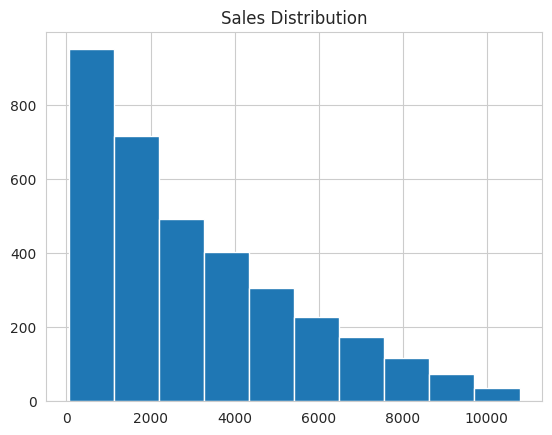

In [38]:
df['Sales'].hist()
plt.title("Sales Distribution")
plt.show()


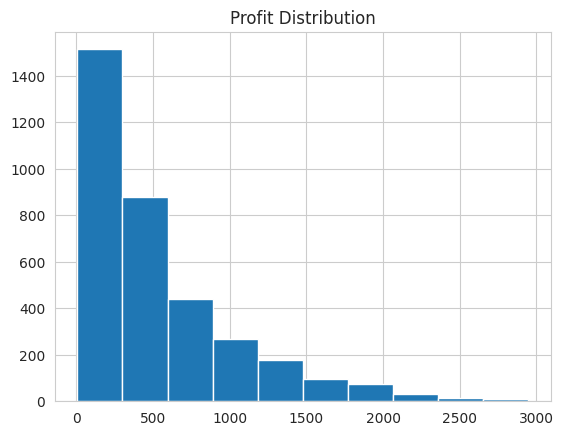

In [39]:
df['Profit'].hist()
plt.title("Profit Distribution")
plt.show()

In [18]:
df['Category'].value_counts()
df['Region'].value_counts()


,count
Region,
West,898
South,883
East,861
North,858


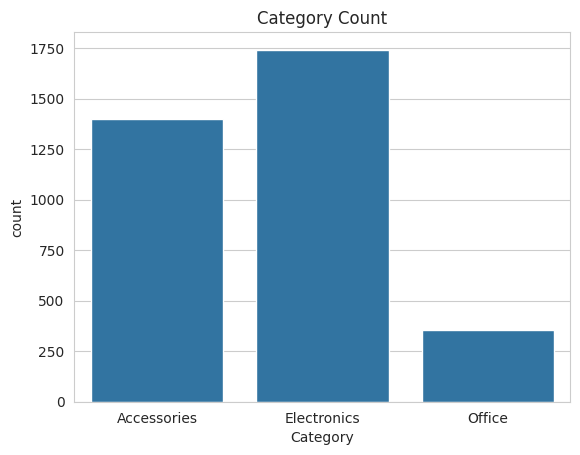

In [40]:
sns.countplot(x='Category', data=df)
plt.title("Category Count")
plt.show()

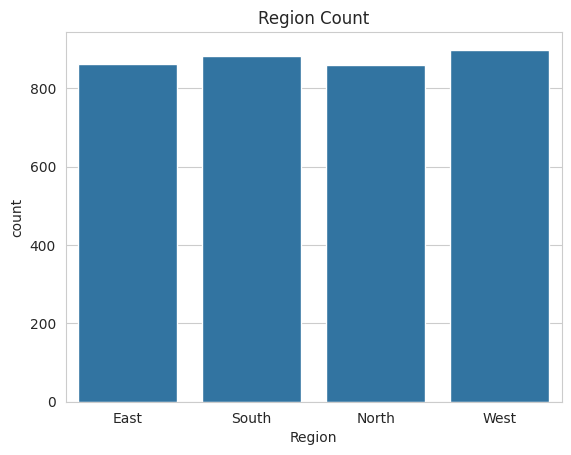

In [41]:
sns.countplot(x='Region', data=df)
plt.title("Region Count")
plt.show()

In [21]:
df[['Sales','Profit','Quantity']].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.832826,0.662468
Profit,0.832826,1.000000,0.560651
Quantity,0.662468,0.560651,1.000000


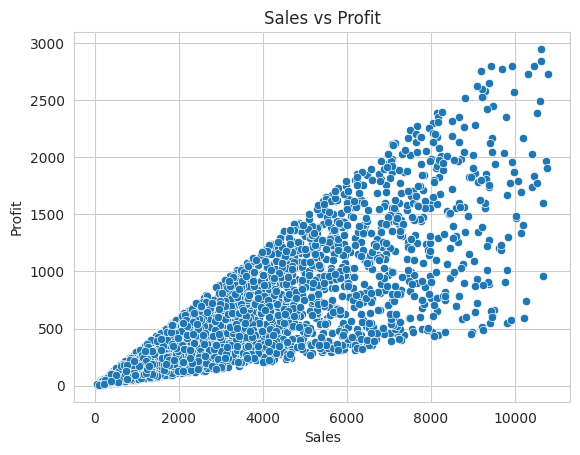

In [42]:
sns.scatterplot(x='Sales', y='Profit', data=df)
plt.title("Sales vs Profit")
plt.show()

In [23]:
df.groupby('Category')['Sales'].sum()

,Sales
Category,
Accessories,4247591
Electronics,5326074
Office,1094216


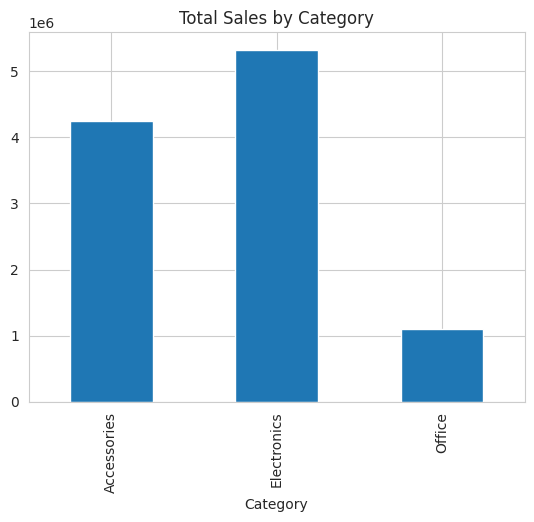

In [43]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Total Sales by Category")
plt.show()

In [25]:
df.groupby('Region')['Profit'].sum()

,Profit
Region,
East,464888.46
North,426314.75
South,458103.27
West,495358.73


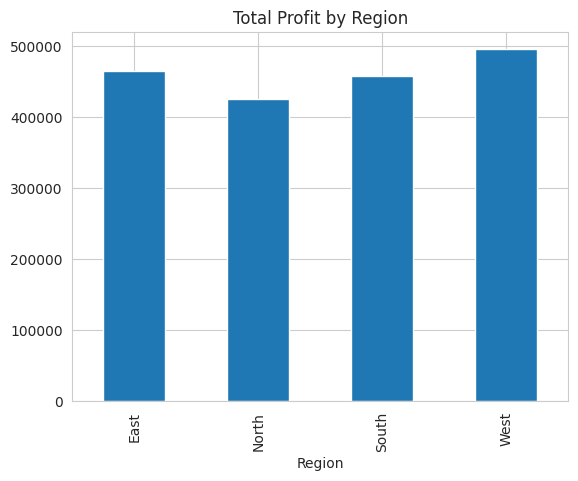

In [44]:
df.groupby('Region')['Profit'].sum().plot(kind='bar')
plt.title("Total Profit by Region")
plt.show()

Top 10 Products by Sales

In [29]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
top_products

,Sales
Product Name,
Camera,1177381
Monitor,1160048
Printer,1094216
Mouse,1074398
Smartphone,1069681
Smartwatch,1049211
Keyboard,1024507
Tablet,1023928
Laptop,1005873


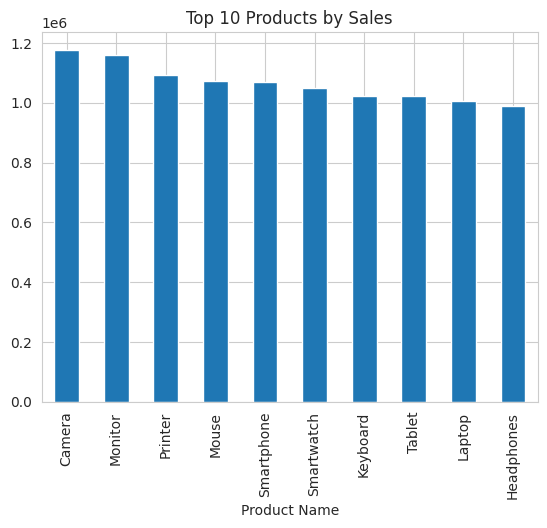

In [45]:
top_products.plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.show()

Time-Based Analysis

In [31]:
df.groupby('Year')['Sales'].sum()

,Sales
Year,
2022,3255970
2023,3786592
2024,3625319


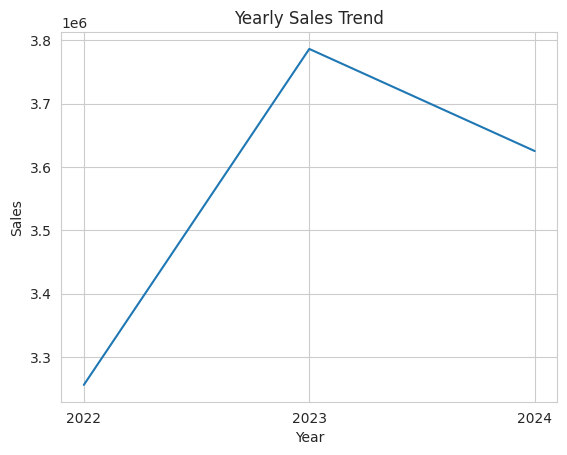

In [46]:

import matplotlib.pyplot as plt


df['Year'] = df['Year'].astype(int)

yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure()
plt.plot(yearly_sales.index, yearly_sales.values)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.xticks(yearly_sales.index)
plt.show()

In [35]:
monthly_sales = df.groupby('Month Name')['Sales'].sum()
monthly_sales

,Sales
Month Name,
April,821876
August,924939
December,959102
February,702414
January,967614
July,844940
June,839805
March,939614
May,1034687


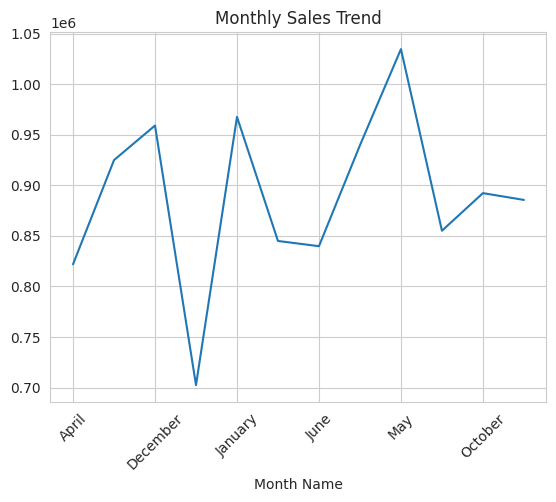

In [51]:
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)
plt.show()

In [52]:
df['Profit Margin %'] = (df['Profit'] / df['Sales']) * 100
df['Profit Margin %'].describe()

,Profit Margin %
count,3500.000000
mean,17.369919
std,7.101922
min,5.004685
25%,11.369866
50%,17.224585
75%,23.343222
max,29.995117


In [53]:
pivot_table = pd.pivot_table(df,
                             values='Sales',
                             index='Region',
                             columns='Category',
                             aggfunc='sum')

pivot_table

Category,Accessories,Electronics,Office
Region,,,
East,1032315,1377211,265584
North,1020641,1244702,223430
South,1076668,1245527,337353
West,1117967,1458634,267849


Key KPIs (For Business Intelligence)

In [54]:
Total_Sales = df['Sales'].sum()
Total_Profit = df['Profit'].sum()
Total_Quantity = df['Quantity'].sum()
Average_Profit_Margin = df['Profit Margin %'].mean()

print("Total Sales:", Total_Sales)
print("Total Profit:", Total_Profit)
print("Total Quantity Sold:", Total_Quantity)
print("Average Profit Margin %:", Average_Profit_Margin)

Total Sales: 10667881
Total Profit: 1844665.21
Total Quantity Sold: 17261
Average Profit Margin %: 17.369919147059417
